Epoch [0/3000], Loss: 0.5603
Epoch [200/3000], Loss: 0.1928
Epoch [400/3000], Loss: 0.1010
Epoch [600/3000], Loss: 0.0288
Epoch [800/3000], Loss: 0.0147
Epoch [1000/3000], Loss: 0.0114
Epoch [1200/3000], Loss: 0.0104
Epoch [1400/3000], Loss: 0.0100
Epoch [1600/3000], Loss: 0.0098
Epoch [1800/3000], Loss: 0.0097
Epoch [2000/3000], Loss: 0.0096
Epoch [2200/3000], Loss: 0.0096
Epoch [2400/3000], Loss: 0.0095
Epoch [2600/3000], Loss: 0.0095
Epoch [2800/3000], Loss: 0.0095


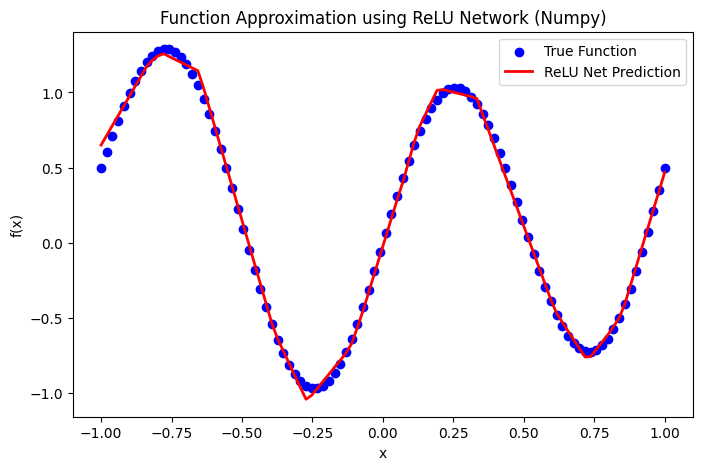

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# 定义目标函数
def target_function(x):
    return np.sin(2 * np.pi * x) + 0.5 * x ** 2

# 生成训练数据和测试数据
np.random.seed(0)
x_train = np.linspace(-1, 1, 500).reshape(-1, 1)  # 训练数据
noise = np.random.normal(0, 0.1, x_train.shape)   # 添加高斯噪声
y_train = target_function(x_train) + noise        # 训练标签
x_test = np.linspace(-1, 1, 100).reshape(-1, 1)   # 测试数据
y_test = target_function(x_test)                  # 测试标签

# 定义 ReLU 激活函数
def relu(x):
    return np.maximum(0, x)

# 定义 ReLU 的导数
def relu_derivative(x):
    return (x > 0).astype(float)

# 定义均方误差损失函数
def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# 定义 Adam 优化器
class AdamOptimizer:
    def __init__(self, params, lr=0.005, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.params = params  # 模型参数
        self.lr = lr          # 学习率
        self.beta1 = beta1    # 一阶矩衰减率
        self.beta2 = beta2    # 二阶矩衰减率
        self.epsilon = epsilon
        self.m = [np.zeros_like(p) for p in params]  # 一阶矩
        self.v = [np.zeros_like(p) for p in params]  # 二阶矩
        self.t = 0  # 时间步

    def step(self, grads):
        self.t += 1
        for i, (param, grad) in enumerate(zip(self.params, grads)):
            # 更新一阶矩和二阶矩
            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * grad
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * (grad ** 2)
            # 偏置修正
            m_hat = self.m[i] / (1 - self.beta1 ** self.t)
            v_hat = self.v[i] / (1 - self.beta2 ** self.t)
            # 更新参数
            param -= self.lr * m_hat / (np.sqrt(v_hat) + self.epsilon)

# 定义两层 ReLU 网络
class ReLUNet:
    def __init__(self, input_size, hidden_size, output_size):
        # 初始化权重和偏置
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01  # 第一层权重
        self.b1 = np.zeros((1, hidden_size))                       # 第一层偏置
        self.W2 = np.random.randn(hidden_size, output_size) * 0.01 # 第二层权重
        self.b2 = np.zeros((1, output_size))                       # 第二层偏置

    def forward(self, x):
        # 前向传播
        self.z1 = np.dot(x, self.W1) + self.b1  # 第一层线性变换
        self.a1 = relu(self.z1)                 # 第一层激活函数
        self.z2 = np.dot(self.a1, self.W2) + self.b2  # 第二层线性变换
        return self.z2  # 输出层（无激活函数）

    def backward(self, x, y_true, y_pred):
        # 反向传播
        m = x.shape[0]  # 样本数量
        # 输出层梯度
        dz2 = (y_pred - y_true) / m
        dW2 = np.dot(self.a1.T, dz2)
        db2 = np.sum(dz2, axis=0, keepdims=True)
        # 隐藏层梯度
        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * relu_derivative(self.z1)
        dW1 = np.dot(x.T, dz1)
        db1 = np.sum(dz1, axis=0, keepdims=True)
        return [dW1, db1, dW2, db2]  # 返回梯度列表

# 初始化模型和优化器
input_size = 1
hidden_size = 64
output_size = 1
model = ReLUNet(input_size, hidden_size, output_size)
optimizer = AdamOptimizer([model.W1, model.b1, model.W2, model.b2], lr=0.005)

# 训练模型
num_epochs = 3000
for epoch in range(num_epochs):
    # 前向传播
    y_pred = model.forward(x_train)
    # 计算损失
    loss = mse_loss(y_train, y_pred)
    # 反向传播
    grads = model.backward(x_train, y_train, y_pred)
    # 更新参数
    optimizer.step(grads)
    
    if epoch % 200 == 0:
        print(f'Epoch [{epoch}/{num_epochs}], Loss: {loss:.4f}')

# 预测测试集
y_pred_test = model.forward(x_test)

# 可视化结果
plt.figure(figsize=(8, 5))
plt.scatter(x_test, y_test, label='True Function', color='blue')
plt.plot(x_test, y_pred_test, label='ReLU Net Prediction', color='red', linewidth=2)
plt.legend()
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Function Approximation using ReLU Network (Numpy)')
plt.show()